In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Paths to raw images and masks

In [2]:
RAW_POSITIVE_IMG_DIR = "../data/raw/images/positive"
RAW_NEGATIVE_IMG_DIR = "../data/raw/images/negative"
RAW_POSITIVE_MASK_DIR = "../data/raw/masks/positive"
RAW_NEGATIVE_MASK_DIR = "../data/raw/masks/negative"

In [3]:
def load_sample_positive(img_name):
    """
    Load a positive sample image and its corresponding mask.
    """
    img_path = os.path.join(RAW_POSITIVE_IMG_DIR, img_name)
    mask_path = os.path.join(RAW_POSITIVE_MASK_DIR, img_name.replace("img", "mask"))
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    return img, mask

def load_sample_negative(img_name):
    """
    Load a negative sample image and its corresponding mask.
    """
    img_path = os.path.join(RAW_NEGATIVE_IMG_DIR, img_name)
    mask_path = os.path.join(RAW_NEGATIVE_MASK_DIR, img_name.replace("img", "mask"))
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    return img, mask

In [13]:
positive_images = os.listdir(RAW_POSITIVE_IMG_DIR)
negative_images = os.listdir(RAW_NEGATIVE_MASK_DIR)
print(f"Positive images: {len(positive_images)}")
print(f"Negative images: {len(negative_images)}")

Positive images: 6882
Negative images: 12060


Loading a sample image and mask

In [4]:
sample_name = os.listdir(RAW_POSITIVE_IMG_DIR)[0]
img, mask = load_sample_positive(sample_name)

Displaying the sample image and mask

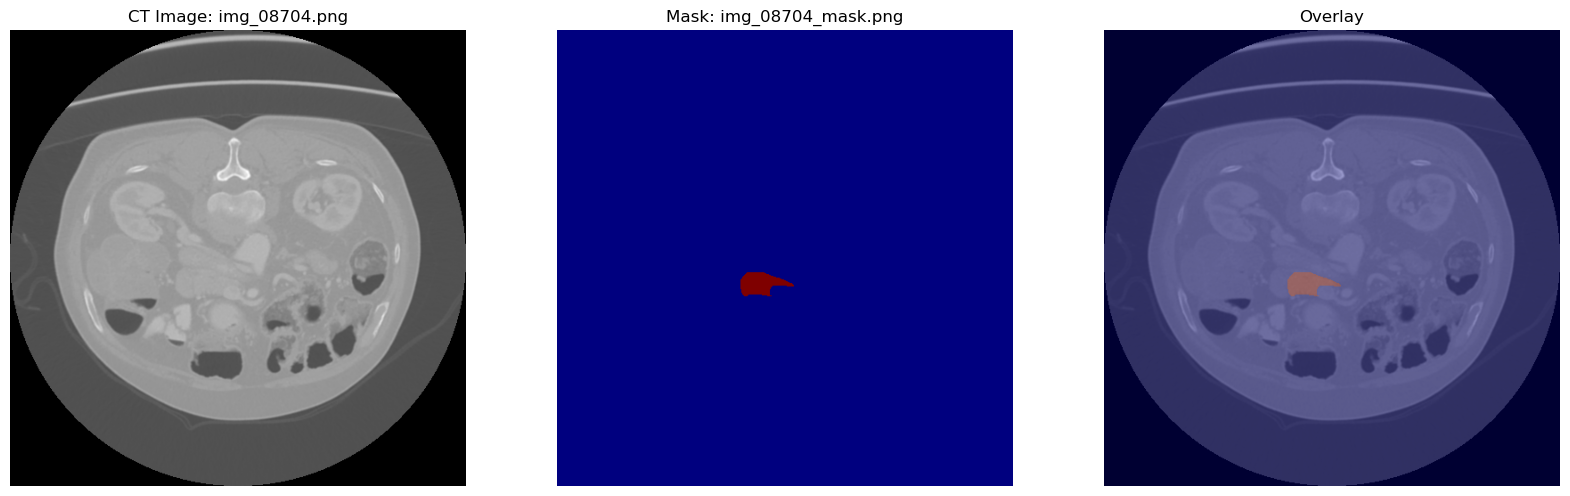

In [5]:
plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plt.title(f"CT Image: {sample_name}")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"Mask: {sample_name.replace('.png', '_mask.png')}")
plt.imshow(mask, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(img, cmap='gray')
plt.imshow(mask, cmap='jet', alpha=0.4)
plt.axis('off')

plt.show()

Analyzing pixel intesity distribution 

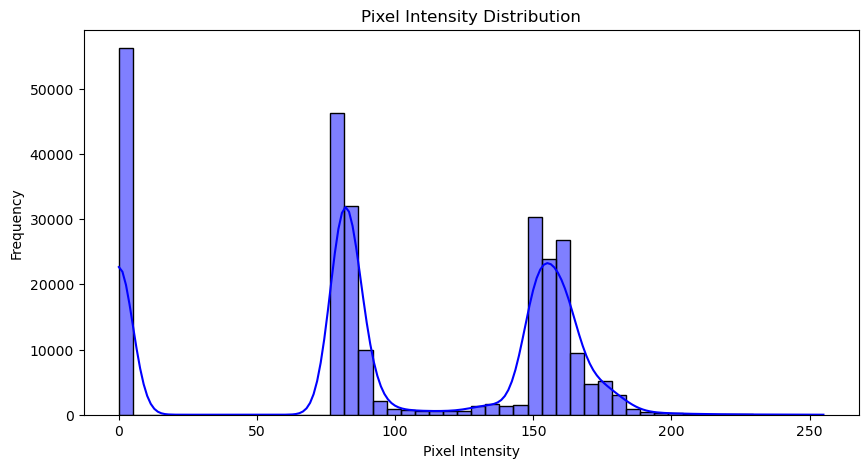

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(img.ravel(), bins=50, kde=True, color='blue')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

Calculating the percentage of pancreas pixels in the mask

In [7]:
pancreas_pixels = np.sum(mask > 0)
total_pixels = mask.size
pancreas_percentage = (pancreas_pixels / total_pixels) * 100
print(f"Pancreas occupies {pancreas_percentage:.2f}% of the image.")

Pancreas occupies 0.38% of the image.


Heatmap to see a average position of the pancreas for 1000 samples

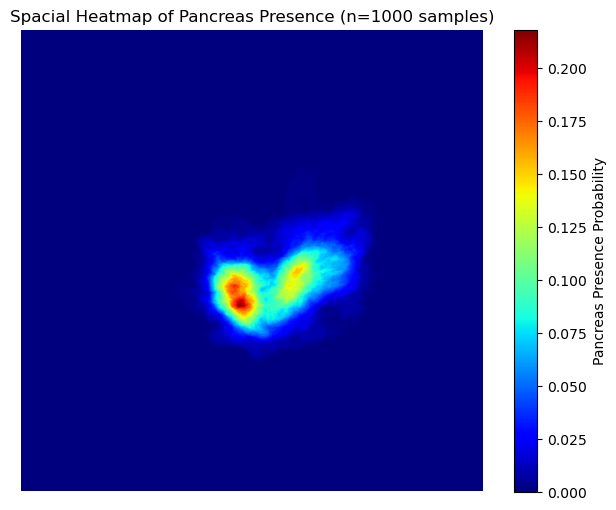

In [8]:
samples_names = os.listdir(RAW_POSITIVE_IMG_DIR)[:1000]
masks = [load_sample_positive(name)[1] for name in samples_names]
sum_mask = np.zeros(masks[0].shape, dtype=np.float32)

# Sum all masks to create a heatmap
count = 0
for mask in masks:
    if mask is not None:
        m_binary = (mask > 0).astype(np.float32)
        sum_mask += m_binary
        count += 1

# Calculate the average mask
average_mask = sum_mask / count

# Visualize the average mask as a heatmap
plt.figure(figsize=(8, 6))
plt.imshow(average_mask, cmap='jet')
plt.colorbar(label='Pancreas Presence Probability')
plt.title(f"Spacial Heatmap of Pancreas Presence (n={count} samples)")
plt.axis('off')
plt.show()


K-Means Clustering

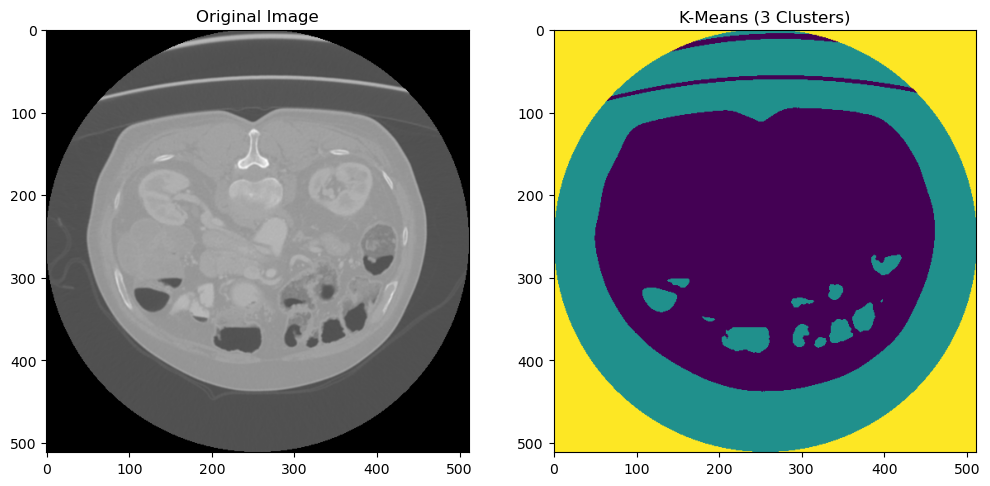

In [9]:
from sklearn.cluster import KMeans

img, mask = load_sample_positive(sample_name)

# Flatten the image and mask for clustering
X = img.reshape(-1, 1)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Reconstruct the clustered image
segmented = kmeans.labels_.reshape(img.shape)

# Plot the result
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(segmented, cmap='viridis')
plt.title("K-Means (3 Clusters)")
plt.show()

DBSCAN

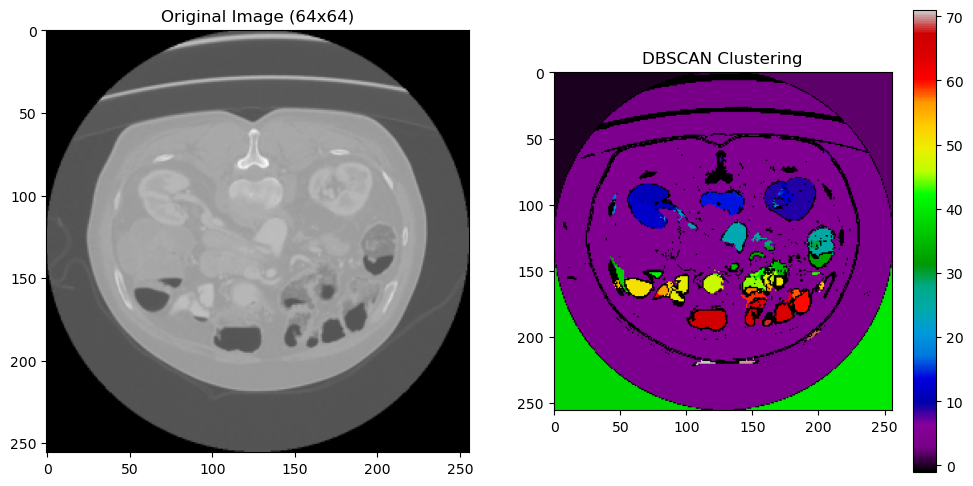

In [10]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# DBSCAN parameters
EPS = 0.05
MIN_SAMPLES = 10

IMG_SIZE = (256, 256)

# Resize the image for faster processing
img_small = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)

# Prepare data for DBSCAN
h, w = img_small.shape
indices = np.indices((h, w)).reshape(2, -1).T
pixel_values = img_small.reshape(-1, 1)

features = np.hstack((pixel_values, indices))

# Normalize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply DBSCAN
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
clusters = dbscan.fit_predict(features_scaled)

# Reconstruct the clustered image
segmented_dbscan = clusters.reshape(h, w)

# Plot the result
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_small, cmap='gray')
plt.title("Original Image (64x64)")

plt.subplot(1, 2, 2)
plt.imshow(segmented_dbscan, cmap='nipy_spectral')
plt.title("DBSCAN Clustering")
plt.colorbar()
plt.show()

k-Nearest Neighbors

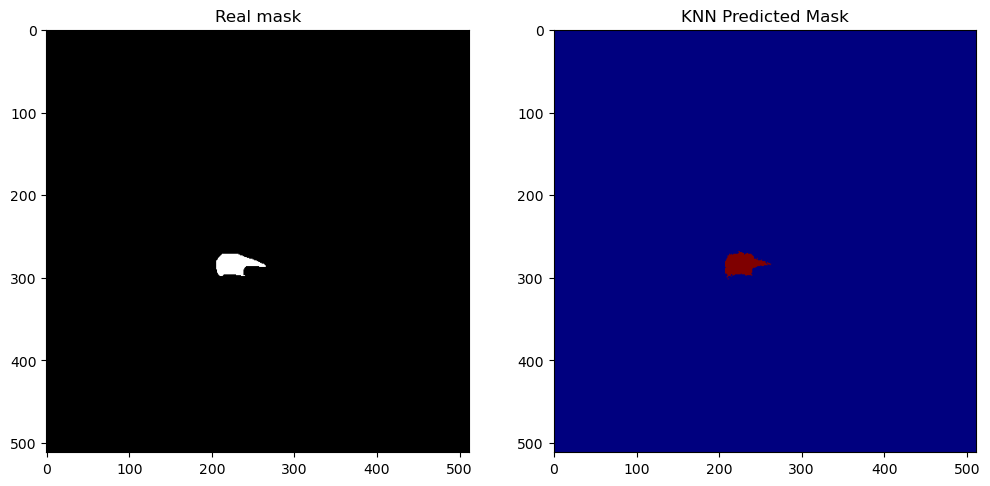

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# KNN parameters
N_NEIGHBORS = 5
IMG_SIZE = (512, 512)

img_small = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
mask_small = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_AREA)

# Prepare data for KNN
h, w = img_small.shape
indices = np.indices((h, w)).reshape(2, -1).T
X = np.hstack((img_small.reshape(-1, 1), indices)) # Features: pixel intensity + spatial coordinates
y = (mask_small.reshape(-1) > 0).astype(int) # Labels: 1 for pancreas, 0 for background

# Sub-sample the data for faster training
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=N_NEIGHBORS)
knn.fit(X_train, y_train)

# Predict on the entire image
y_pred = knn.predict(X)
segmented_knn = y_pred.reshape(h, w)

# Plot the result
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Real mask")
plt.imshow(cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_AREA), cmap='gray')

plt.subplot(1, 2, 2)
plt.title("KNN Predicted Mask")
plt.imshow(segmented_knn, cmap='jet')
plt.show()

In [12]:
from sklearn.metrics import f1_score

# Calculate F1 score
dice = f1_score(y, y_pred)
print(f"Dice Coefficient (F1 Score) for KNN: {dice:.4f}")

Dice Coefficient (F1 Score) for KNN: 0.9307
